In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Research Supervisor Agent

To delegate research tasks to an appropriate no. of sub-agents

#### Design choices

**Why supervisor, or even multiple agents at all?**

- Single agent can suffer with response quality when working on multiple topics
- Could cause context-clash or overload context window especially when working across topics with all research content, tool results, feedback, etc.
- Could be expensive, but much faster with improved accuracy.

**What features does this agent should contain?**
- Carefully assess the question and decide how to delegate research - whether some topics can be explored simultaneously, or need different approach.
- Be efficient: Prefer single agent unless it sub-agents are really needed (For example: `List top 10 AI models` -> 1 sub-agent, but `Compare opus-4-7 with codex-5-5 in terms of efficienty` -> 2 sub-agents)
- How can a big task be broken down into multiple smaller sub-tasks

## Agent Setup

In [2]:
from src.agent_prompts import lead_researcher_prompt

### State setup

We've defined two tools here instead of functions to let LLM perform structured decision-making

**Tools = buttons LLM presses. Structured output = form LLM fills.**

- **Branch**: LLM picks `ConductResearch` vs `ResearchComplete`. Tool name routes graph.
- **Parallel**: One turn → N tool_calls → N Send fan-outs.
- **Loop**: ToolMessage(tool_call_id=...) closes pair, feeds next turn until ResearchComplete.
- **Schema**: Pydantic validates research_topic arg.
- `with_structured_output` = one-shot extraction. No branching, no parallel, no loop closure. Wrong primitive for supervisor.

In [3]:
# %%writefile ./main/state_multi_agent_supervisor.py

"""
State Definitions for Multi-Agent Research Supervisor

This module defines the state objects and tools used for the multi-agent
research supervisor workflow, including coordination state and research tools.
"""

import operator
from typing import Annotated, TypedDict, Sequence

from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

class SupervisorState(TypedDict):
    """
    State object for the research supervisor workflow.
    """
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages] # messages exchanged between the supervisor and researchers for coordination and decision-making
    research_brief: str
    notes: Annotated[list[str], operator.add] # notes taken by the supervisor during the research process for final-report compilation
    research_iterations: int # number of research iterations completed, used for tracking progress and determining when to compile the final report
    raw_notes: Annotated[list[str], operator.add] # raw notes collected from researchers

@tool
class ConductResearch(BaseModel):
    """
    Tool for delegating a research task to a specialized sub-agent.
    """
    research_topic: str = Field(..., description="The specific topic or question to research described in high-level terms.")

@tool
class ResearchComplete(BaseModel): # A dummy tool placeholder - which will be set in full agent implementation
    """
    Tool for marking the completion of a research task by a sub-agent.
    """
    pass 

### Multi-agent

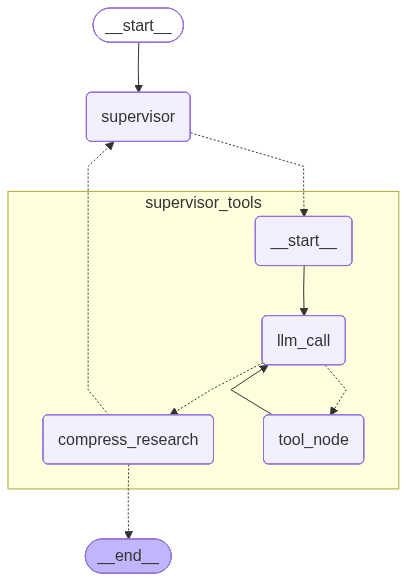

In [4]:
# %%writefile ./src/multi_agent_supervisor.py

"""
Multi-agent supervisor for coordinating research across multiple specialized agents.

This module implements a supervisor pattern where:
1. A supervisor agent coordinates research activities and delegates tasks
2. Multiple researcher agents work on specific sub-topics independently
3. Results are aggregated and compressed for final reporting

The supervisor uses parallel research execution to improve efficiency while
maintaining isolated context windows for each research topic.
"""
import asyncio # for usage in jupyter environments, ensure async compatibility

from typing import Literal
from langchain_core.messages import (
    HumanMessage, 
    BaseMessage, 
    SystemMessage, 
    ToolMessage,
    filter_messages
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_anthropic import ChatAnthropic

from src.agent_prompts import lead_researcher_prompt
from src.research_agent import researcher_agent
from src.state_multi_agent_supervisor import SupervisorState, ConductResearch, ResearchComplete
from src.agent_tools import think_tool
from src.utils import date_today_str

def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """
    Extract notes from ToolMessage instances in the message history.

    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.
    
    Args:
        messages: List of messages from supervisor's conversation history
        
    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    tool_messages = filter_messages(messages, include_types="tool")
    
    notes = [msg.content for msg in tool_messages if isinstance(msg.content, str)]
    
    return notes

# Ensure async compatibility for Jupyter environments
try:
    import nest_asyncio
    # Only apply if running in Jupyter/IPython environment
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass  # Not in Jupyter, no need for nest_asyncio
except ImportError:
    pass  # nest_asyncio not available, proceed without it

########### INITIALIZATION ##########

model = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)
supervisor_tools = [ConductResearch, ResearchComplete, think_tool]
supervisor_model = model.bind_tools(supervisor_tools)

# Conservative caps for learning-mode runs. Scale up for richer briefs once
# the graph is verified to terminate cleanly end-to-end.
max_research_iterations = 3 # maximum number of research iterations before supervisor compiles final report
max_concurrent_researchers = 2 # maximum number of concurrent researcher agents to run in parallel for efficiency

########### SUPERVISOR AGENT IMPLEMENTATION ##########

# Nodes

async def supervisor(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """
    Coordinate research activities.
    
    Analyzes the research brief and current progress to decide:
    - What research topics need investigation
    - Whether to conduct parallel research
    - When research is complete
    
    Args:
        state: Current supervisor state with messages and research progress
        
    Returns:
        Command to proceed to supervisor_tools node with updated state
    """

    supervisor_messages = state.get("supervisor_messages", []) # check existing messages shared with supervisor

    lead_researcher_system_prompt = lead_researcher_prompt.format(
        date=date_today_str(),
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_research_iterations
    )

    messages = [SystemMessage(content=lead_researcher_system_prompt)] + supervisor_messages

    response = await supervisor_model.ainvoke(messages)

    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )

async def supervisor_tools(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """
    Execute supervisor decisions - either conduct research or end the process.
    
    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete
    
    Args:
        state: Current supervisor state with messages and iteration count
        
    Returns:
        Command to continue supervision, end process, or handle errors
    """

    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]

    # Initialize variables for single return pattern
    tool_messages = []
    raw_notes_batch = []
    next_step = "supervisor"  # Default next step
    should_end = False

    ##### EXIT CRITERIA CHECKS
    exceeded_iterations = research_iterations >= max_research_iterations
    no_tool_calls = not most_recent_message.tool_calls # if no tool calls, treat as exit criteria to prevent infinite loops
    research_complete = any(
        tool_call["name"] == "ResearchComplete" 
        for tool_call in most_recent_message.tool_calls
    ) # if ResearchComplete tool was called, treat as exit criteria

    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END
    
    else:
        try:
            # Separate each tool calls (since we have both synchronous think_tool calls and asynchronous ConductResearch calls in the same message, we need to handle them separately)
            think_tool_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "think_tool"
            ]
            
            conduct_research_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "ConductResearch"
            ]

            # Handle think_tool calls (synchronous)
            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    )
                )

            # Handle ConductResearch calls (asynchronous)
            if conduct_research_calls:
                # IMPORTANT PART: every invocation of a research agent is an independent async call, allowing for parallel execution of multiple research agents without blocking the supervisor's workflow. Each researcher agent will work on its assigned research topic in isolation, and the supervisor can await all of them to complete before proceeding with result aggregation.
                researcher_invokations = [
                    researcher_agent.ainvoke({
                        "researcher_messages": [
                            HumanMessage(content=tool_call["args"]["research_topic"])
                        ],
                        "research_topic": tool_call["args"]["research_topic"]
                    }) 
                    for tool_call in conduct_research_calls
                ]

                # Wait for all research to complete
                tool_results = await asyncio.gather(*researcher_invokations)

                # Format research results as tool messages
                # Each sub-agent returns compressed research findings in result["compressed_research"]
                # We write this compressed research as the content of a ToolMessage, which allows
                # the supervisor to later retrieve these findings via get_notes_from_tool_calls()
                research_tool_messages = [
                    ToolMessage(
                        content=result.get("compressed_research", "Error synthesizing research report"),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    ) for result, tool_call in zip(tool_results, conduct_research_calls)
                ]
                
                tool_messages.extend(research_tool_messages)

                # Aggregate raw notes from this batch of researchers; the operator.add
                # reducer on SupervisorState.raw_notes appends them to prior batches.
                raw_notes_batch = [
                    "\n".join(result.get("raw_notes", [])) 
                    for result in tool_results
                ]
        
        except Exception as e:
            print(f"Error in supervisor tools: {e}")
            should_end = True
            next_step = END

    # Single return point with appropriate state updates
    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", "")
            }
        )
    else:
        return Command(
            goto=next_step,
            update={
                "supervisor_messages": tool_messages,
                "raw_notes": raw_notes_batch
            }
        )
    
######### STATE GRAPH DEFINITION ##########
supervisor_graph = StateGraph(SupervisorState)

supervisor_graph.add_node("supervisor", supervisor)
supervisor_graph.add_node("supervisor_tools", supervisor_tools)

supervisor_graph.add_edge(START, "supervisor") # loop back to supervisor for next iteration of coordination

supervisor_agent = supervisor_graph.compile()


from IPython.display import Image, display
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

## Testing

In [5]:
from src.utils import format_messages
from langchain_core.messages import HumanMessage

# Smoke-test brief: single area, narrow scope. Scale back up to the full
# 5-area brief once the graph is verified to terminate cleanly.
research_brief = """
I am learning about Agentic AI best practices for production environments. Please provide a focused
educational deep-dive on **System Design & Architecture** for production agentic AI systems, covering:
agent orchestration, multi-agent frameworks, tool use, memory management, context window handling,
modularity, and scalability.

Ground the research in current (up to May 2026) industry knowledge. Prioritize authoritative primary
sources such as official documentation from leading AI labs and frameworks (OpenAI, Anthropic, Google
DeepMind, LangChain, AutoGen, CrewAI), peer-reviewed research, and well-regarded engineering blogs.
The audience is a learner seeking actionable guidance with concrete examples.
"""

response = await supervisor_agent.ainvoke({
    "supervisor_messages": [HumanMessage(content=research_brief)]
})

format_messages(response["supervisor_messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ I am learning about Agentic AI best practices for production environments. Please provide a focused             │
│ educational deep-dive on **System Design & Architecture** for production agentic AI systems, covering:          │
│ agent orchestration, multi-agent frameworks, tool use, memory management, context window handling,              │
│ modularity, and scalability.                                                                                    │
│                                                                                                                 │
│ Ground the research in current (up to May 2026) industry knowledge. Prioritize authoritative primary            │
│ sources such as official documentation from leading AI labs and frameworks (OpenAI, Anthropic, Google           │
│ DeepMind, LangChain, AutoGen, CrewAI), peer-reviewed research, and well-regarded engineering blogs.             │
│ The audience is a learner seeking actionable guidance with concrete examples.                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The user wants a comprehensive educational deep-dive on System Design & Architecture for       │
│ production agentic AI systems. This is a multi-faceted topic covering:\n\n1. Agent orchestration\n2.            │
│ Multi-agent frameworks\n3. Tool use\n4. Memory management\n5. Context window handling\n6. Modularity\n7.        │
│ Scalability\n\nThis is a rich, complex topic that benefits from parallel research. I can break this into two    │
│ parallel research tracks:\n\n**Track 1**: Agent orchestration, multi-agent frameworks, and tool use - covering  │
│ the structural/coordination aspects\n**Track 2**: Memory management, context window handling, modularity, and   │
│ scalability - covering the resource/architecture aspects\n\nBoth tracks are independent and can be researched   │
│ simultaneously. This will give comprehensive coverage across all the requested topics. Let me delegate these    │
│ two parallel research tasks."                                                                                   │
│ }                                                                                                               │
│    ID: toolu_01GLmmMF819SUw2K74Aa1qdK                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The user wants a comprehensive educational deep-dive on System Design & Architecture for   │
│ production agentic AI systems. This is a multi-faceted topic covering:                                          │
│                                                                                                                 │
│ 1. Agent orchestration                                                                                          │
│ 2. Multi-agent frameworks                                                                                       │
│ 3. Tool use                                                                                                     │
│ 4. Memory management                                                                                            │
│ 5. Context window handling                                                                                      │
│ 6. Modularity                                                                                                   │
│ 7. Scalability                                                                                                  │
│                                                                                                                 │
│ This is a rich, complex topic that benefits from parallel research. I can break this into two parallel research │
│ tracks:                                                                                                         │
│                                                                                                                 │
│ **Track 1**: Agent orchestration, multi-agent frameworks, and tool use - covering the structural/coordination   │
│ aspects                                                                                                         │
│ **Track 2**: Memory management, context window handling, modularity, and scalability - covering the             │
│ resource/architecture aspects                                                                                   │
│                                                                                                                 │
│ Both tracks are independent and can be researched simultaneously. This will give comprehensive coverage across  │
│ all the requested topics. Let me delegate these two parallel research tasks.                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Production agentic AI system design: agent orchestration patterns, multi-agent frameworks, │
│ and tool use best practices (up to May 2026). Cover: (1) orchestration architectures such as single-agent       │
│ loops, hierarchical multi-agent systems, and peer-to-peer agent networks; (2) leading frameworks including      │
│ OpenAI Agents SDK, Anthropic Claude tool use, LangChain/LangGraph, AutoGen (Microsoft), CrewAI, and Google      │
│ Gemini agents \u2014 with their design philosophies, strengths, and trade-offs; (3) tool use patterns including │
│ function calling, Model Context Protocol (MCP), tool schemas, error handling, and retry logic; (4) concrete     │
│ production examples and actionable guidance. Prioritize official documentation, engineering blogs from AI labs, │
│ and authoritative technical sources."                                                                           │
│ }                                                                                                               │
│    ID: toolu_01TcRjYW8JZbqiAhedXPnxGK                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Production agentic AI system design: memory management, context window handling,           │
│ modularity, and scalability best practices (up to May 2026). Cover: (1) memory types in agentic systems \u2014  │
│ in-context (working memory), external/long-term memory (vector databases, knowledge graphs), episodic memory,   │
│ and semantic memory \u2014 with concrete implementation patterns; (2) context window management strategies      │
│ including summarization, retrieval-augmented generation (RAG), sliding windows, and token budgeting; (3)        │
│ modular agent architecture patterns \u2014 separation of concerns, agent-as-microservice, plugin architectures; │
│ (4) scalability patterns including horizontal scaling, stateless agents, async execution, queue-based task      │
│ dispatch, and fault tolerance; (5) concrete production examples and actionable guidance. Prioritize official    │
│ documentation, engineering blogs from AI labs (OpenAI, Anthropic, Google DeepMind, LangChain), and              │
│ authoritative technical sources."                                                                               │
│ }                                                                                                               │
│    ID: toolu_01MFX3ZoVmaktt8sjGvXKRgR                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ # Cleaned Research Findings: Production Agentic AI System Design                                                │
│                                                                                                                 │
│ ## List of Queries and Tool Calls Made                                                                          │
│                                                                                                                 │
│ 1. "Agentic AI system design orchestration patterns multi-agent frameworks 2024 2025"                           │
│ 2. "OpenAI Agents SDK design philosophy swarm handoffs 2025 production"                                         │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Fully Comprehensive Findings                                                                                 │
│                                                                                                                 │
│ ### 1. Overview of Agentic AI Frameworks and Architecture (2025)                                                │
│                                                                                                                 │
│ #### Core Definition and Components                                                                             │
│ Agentic AI frameworks are technical architectures that enable autonomous AI agents to perceive inputs, make     │
│ decisions, and execute actions without constant human direction. These frameworks consist of six core           │
│ interconnected components [1]:                                                                                  │
│ - **Perception** (data ingestion)                                                                               │
│ - **Cognitive** (decision-making)                                                                               │
│ - **Action** (task execution)                                                                                   │
│ - **Learning** (adaptive improvement)                                                                           │
│ - **Collaboration** (multi-agent coordination)                                                                  │
│ - **Security** (threat protection)                                                                              │
│                                                                                                                 │
│ Key features include: pre-built modules, memory management, multi-agent collaboration, planning and reasoning,  │
│ customized decision-making, self-learning capabilities, and contextual awareness [1].                           │
│                                                                                                                 │
│ "Agentic frameworks provide the core architecture for complex AI systems, enabling multiple agents to interact, │
│ reason, and adapt within dynamic environments. In contrast, AI agent builders are user-friendly development     │
│ platforms." [1]                                                                                                 │
│                                                                                                                 │
│ #### Market Context and Scale                                                                                   │
│ - Enterprise spending on generative AI reached **$37 billion in 2025**, a **3.2x increase from 2024** [3].      │
│ - According to Gartner, agentic AI will autonomously ha

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ # Cleaned Research Findings: Production Agentic AI System Design                                                │
│                                                                                                                 │
│ ## List of Queries and Tool Calls Made                                                                          │
│                                                                                                                 │
│ 1. **Query**: "production agentic AI system design memory management context window 2024 2025"                  │
│ 2. **Query**: "LangChain LangGraph agent memory architecture vector database episodic semantic memory           │
│ production 2025"                                                                                                │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Fully Comprehensive Findings                                                                                 │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. Context Engineering as a Discipline (2025–2026)                                                          │
│                                                                                                                 │
│ #### Overview and Framing                                                                                       │
│                                                                                                                 │
│ From meta-intelligence.tech [1]:                                                                                │
│ - "Over 70% of errors in modern LLM applications stem not from insufficient model capability but from           │
│ incomplete, irrelevant, or poorly structured context. In 2026, when model capabilities are already sufficiently │
│ powerful, the critical bottleneck determining the success or failure of AI applications has shifted from the    │
│ 'model side' to the 'context side.'"                                                                            │
│ - "If Prompt Engineering is 'writing a good letter,' then Context Engineering is 'building the entire postal    │
│ system.'"                                                                                                       │
│ - "A model's 'intelligence' is increasingly less constrained by the model itself and increasingly more          │
│ determined by the quality of context we provide. This is precisely why Context Engineering is emerging as an    │
│ independent engineering discipline."                                                                            │
│                                                                                                                 │
│ From mem0.ai [2]:                                                                                               │
│ - "Context engineering focuses on the systematic design of information flow to AI agents, moving beyond simple  │
│ prompting to sophisticated context management for production-ready applications."                               │
│ - "Most AI agent failures are context failures rather than model failures—the problem lies in the information   │
│ fed to the system, not the underlying LLM."            

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I now have comprehensive research from both parallel tracks. Let me assess what I              │
│ have:\n\n**Track 1 (Orchestration, Frameworks, Tool Use)**:\n- ReAct framework and agent loop patterns\n-       │
│ Multi-agent orchestration patterns (sequential, parallel fan-out, hierarchical, handoff networks)\n- OpenAI     │
│ Swarm (educational) vs OpenAI Agents SDK (production, March 2025)\n- LangGraph, AutoGen/Microsoft Agent         │
│ Framework, CrewAI\n- Model Context Protocol (MCP) by Anthropic - de facto standard\n- Production deployment     │
│ guidance\n\n**Track 2 (Memory, Context, Modularity, Scalability)**:\n- Context engineering as a discipline      │
│ (2025-2026)\n- Four-layer memory architecture (working, episodic, semantic, system of record)\n- LangChain      │
│ memory documentation (short-term vs long-term)\n- RAG evolution (Naive \u2192 Advanced \u2192 Agentic RAG)\n-   │
│ Context window optimization strategies\n- LangGraph modular architecture\n- Scalability patterns (async, state  │
│ management, versioning)\n\n**Gaps I notice**:\n- Tool use patterns beyond MCP are somewhat thin - I have MCP    │
│ mentioned but not deep detail on function calling schemas, error handling, retry logic\n- CrewAI specifics are  │
│ barely mentioned\n- Google Gemini/DeepMind agent specifics are missing\n- Anthropic's specific agent design     │
│ guidance (beyond MCP) is thin\n\nHowever, given the hard limit of 3 tool calls, and the fact that I have very   │
│ rich, actionable content across all the major topics requested, I think I have enough to write a comprehensive  │
│ educational deep-dive. The research covers:\n\u2705 Agent orchestration (ReAct, hierarchical, sequential,       │
│ parallel, handoff)\n\u2705 Multi-agent frameworks (OpenAI Agents SDK, LangGraph, AutoGen, MCP)\n\u2705 Tool use │
│ (MCP, function calling mentioned)\n\u2705 Memory management (4-layer architecture, LangChain docs)\n\u2705      │
│ Context window handling (RAG evolution, optimization strategies, context engineering)\n\u2705 Modularity        │
│ (LangGraph primitives, separation of concerns)\n\u2705 Scalability (async patterns, state management,           │
│ versioning)\n\nThe content is rich enough for a comprehensive educational deep-dive. I'll call ResearchComplete │
│ and let the report writer synthesize this into a well-structured educational piece."                            │
│ }                                                                                                               │
│    ID: toolu_01XomU28YDn5S3DJEdkFeZFj                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Checkout LangSmith Tracing [here](https://smith.langchain.com/public/e1289e30-2c61-4ff8-ae3e-ae6f68382301/r)